In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_trans = pd.read_csv('../data/train_transaction.csv', nrows=10000)
train_iden  = pd.read_csv('../data/train_identity.csv')

print(f"Transaction: {train_trans.shape}")
print(f"Identity: {train_iden.shape}")


Transaction: (10000, 394)
Identity: (144233, 41)


Tổng số cột có null: 287

Top 15 cột nhiều null nhất:
D7       97.8
D13      97.2
dist2    96.2
D12      95.9
D14      95.5
D6       95.1
D9       89.0
D8       89.0
V160     86.2
V159     86.2
V158     86.2
V157     86.2
V156     86.2
V155     86.2
V154     86.2
dtype: float64


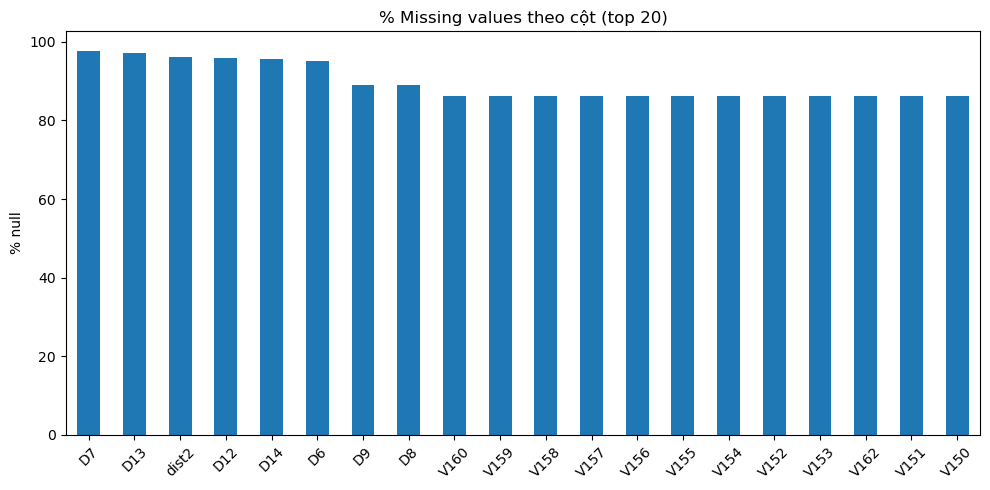

In [3]:
# Tính % null từng cột
missing_pct = (train_trans.isnull().sum() / len(train_trans) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"Tổng số cột có null: {len(missing_pct)}")
print(f"\nTop 15 cột nhiều null nhất:")
print(missing_pct.head(15).round(1))

# Vẽ biểu đồ
plt.figure(figsize=(10,5))
missing_pct.head(20).plot(kind='bar')
plt.title('% Missing values theo cột (top 20)')
plt.ylabel('% null')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Drop cột có >50% null
threshold = 50
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"Số cột bị drop (>50% null): {len(cols_to_drop)}")

train_clean = train_trans.drop(columns=cols_to_drop)
print(f"Shape sau drop: {train_clean.shape}")

# Fill null còn lại
# Cột số → fill bằng median
num_cols = train_clean.select_dtypes(include=['float64','int64']).columns
train_clean[num_cols] = train_clean[num_cols].fillna(train_clean[num_cols].median())

# Cột text → fill bằng 'Unknown'
cat_cols = train_clean.select_dtypes(include=['object']).columns
train_clean[cat_cols] = train_clean[cat_cols].fillna('Unknown')

# Kiểm tra còn null không
remaining_null = train_clean.isnull().sum().sum()
print(f"\nNull còn lại sau xử lý: {remaining_null}")

Số cột bị drop (>50% null): 208
Shape sau drop: (10000, 186)

Null còn lại sau xử lý: 0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = train_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Số cột category cần encode: {len(cat_cols)}")
print(f"Tên cột: {cat_cols}")

for col in cat_cols:
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))

print("\nSau encoding:")
print(train_clean[cat_cols].head(3))

Số cột category cần encode: 6
Tên cột: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M4', 'M6']

Sau encoding:
   ProductCD  card4  card6  P_emaildomain  M4  M6
0          4      2      1              0   2   1
1          4      3      1             17   0   1
2          4      4      2             32   0   0


In [6]:
train_clean.to_csv('../data/train_clean.csv', index=False)
print(f"Đã lưu train_clean.csv!")
print(f"Shape cuối: {train_clean.shape}")
print(f"\nPhân phối fraud sau xử lý:")
print(train_clean['isFraud'].value_counts())

Đã lưu train_clean.csv!
Shape cuối: (10000, 186)

Phân phối fraud sau xử lý:
isFraud
0    9735
1     265
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/train_clean.csv')
print(f"Shape: {df.shape}")
print(f"Cột TransactionDT: {df['TransactionDT'].describe()}")

Shape: (10000, 186)
Cột TransactionDT: count     10000.000000
mean     186909.442000
std       56572.671722
min       86400.000000
25%      146628.750000
50%      171644.000000
75%      240112.000000
max      313121.000000
Name: TransactionDT, dtype: float64


In [8]:
# TransactionDT là số giây tính từ một mốc cố định
# Chuyển thành các feature có ý nghĩa

df['hour']       = (df['TransactionDT'] / 3600) % 24        # Giờ trong ngày (0-23)
df['dayofweek']  = (df['TransactionDT'] / (3600*24)) % 7    # Thứ trong tuần (0-6)
df['day']        = (df['TransactionDT'] / (3600*24)) % 30   # Ngày trong tháng

print("Time features mới:")
print(df[['TransactionDT','hour','dayofweek','day']].head())

Time features mới:
   TransactionDT      hour  dayofweek       day
0          86400  0.000000   1.000000  1.000000
1          86401  0.000278   1.000012  1.000012
2          86469  0.019167   1.000799  1.000799
3          86499  0.027500   1.001146  1.001146
4          86506  0.029444   1.001227  1.001227


In [14]:
# Tính lại đúng cách
df['hour']      = (df['TransactionDT'] // 3600 % 24).astype(int)
df['dayofweek'] = (df['TransactionDT'] // 86400 % 7).astype(int)

print("Unique hours:", sorted(df['hour'].unique()))
print("Unique dayofweek:", sorted(df['dayofweek'].unique()))

Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Unique dayofweek: [np.int64(1), np.int64(2), np.int64(3)]


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Round và chỉ lấy các giá trị hợp lệ
hour_fraud = df.groupby('hour')['isFraud'].mean().mul(100)
hour_fraud = hour_fraud[hour_fraud.index < 24].sort_index()

day_fraud = df.groupby('dayofweek')['isFraud'].mean().mul(100)
day_fraud = day_fraud[day_fraud.index < 7].sort_index()

hour_fraud.plot(kind='bar', color='coral', ax=axes[0])
axes[0].set_title('Fraud theo giờ trong ngày')
axes[0].set_xlabel('Giờ (0-23)')
axes[0].set_ylabel('% Fraud')

day_fraud.plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Fraud theo thứ trong tuần')
axes[1].set_xlabel('Thứ (0-6)')
axes[1].set_ylabel('% Fraud')

plt.tight_layout()
plt.savefig('../reports/fraud_by_time_3.png', dpi=80, bbox_inches='tight')
plt.close()
print("Xong! Mở file reports/fraud_by_time_3.png xem!")

Xong! Mở file reports/fraud_by_time_3.png xem!


In [16]:
# Sắp xếp theo thời gian trước
df = df.sort_values('TransactionDT').reset_index(drop=True)

# Số giao dịch trong cùng card (C1) gần đây
# Dùng rolling count theo card
df['card1_freq'] = df.groupby('card1')['TransactionAmt'].transform('count')
df['card1_avg_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amt'] = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

# Độ lệch số tiền so với trung bình của card đó
df['amt_diff_from_avg'] = df['TransactionAmt'] - df['card1_avg_amt']

print("Velocity features:")
print(df[['card1','TransactionAmt','card1_freq','card1_avg_amt','amt_diff_from_avg']].head(10))

Velocity features:
   card1  TransactionAmt  card1_freq  card1_avg_amt  amt_diff_from_avg
0  13926            68.5           1      68.500000           0.000000
1   2755            29.0          12     162.487500        -133.487500
2   4663            59.0          21     111.839524         -52.839524
3  18132            50.0          96     135.951667         -85.951667
4   4497            50.0           1      50.000000           0.000000
5   5937            49.0           1      49.000000           0.000000
6  12308           159.0           5      57.600000         101.400000
7  12695           422.5         104     106.462587         316.037413
8   2803            15.0         104     141.552212        -126.552212
9  17399           117.0          24     124.460000          -7.460000


In [17]:
df.to_csv('../data/train_features.csv', index=False)
print(f"Đã lưu train_features.csv!")
print(f"Shape cuối: {df.shape}")
print(f"Số features mới thêm: {df.shape[1] - 202}")

Đã lưu train_features.csv!
Shape cuối: (10000, 193)
Số features mới thêm: -9
